# 绿的谐波 (688017.SH) 技术指标分析

**股票代码**：688017.SH | **板块**：科创板 | **行业**：机械基件  
**数据范围**：2025-07-03 ~ 2026-07-03 | **交易日数**：243  |
**分析指标**：RSI / MACD / 布林带 / ATR

---

In [1]:
# ============================================================
# 环境配置
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import mplfinance as mpf
import warnings
warnings.filterwarnings('ignore')

# ---- 中文字体设置 ----
from matplotlib.font_manager import fontManager
candidates = ['Microsoft YaHei', 'SimHei', 'KaiTi', 'FangSong', 'STSong']
available = {f.name for f in fontManager.ttflist}
font_name = None
for c in candidates:
    if c in available:
        font_name = c
        break
if font_name:
    FONT_RC = {
        'font.family': 'sans-serif',
        'font.sans-serif': [font_name, 'DejaVu Sans'],
        'axes.unicode_minus': False,
    }
    plt.rcParams.update(FONT_RC)
    print(f'中文字体: {font_name}')
else:
    print('⚠ 未找到中文字体，可能显示乱码')
    FONT_RC = {
        'font.family': 'sans-serif',
        'font.sans-serif': ['DejaVu Sans'],
        'axes.unicode_minus': False,
    }
    plt.rcParams.update(FONT_RC)

# 图表默认配置
plt.rcParams['figure.dpi'] = 100
%matplotlib inline
print("环境配置完成 ✓")

中文字体: Microsoft YaHei
环境配置完成 ✓


In [2]:
# ============================================================
# 数据加载与预处理
# ============================================================
CSV_PATH = r'C:\Users\27924\Desktop\QuantStudy\Task1\绿的谐波_日线数据.csv'

df = pd.read_csv(CSV_PATH)
df.rename(columns={
    '交易日期': 'date',
    '开盘价': 'open',
    '最高价': 'high',
    '最低价': 'low',
    '收盘价': 'close',
    '成交量(手)': 'volume',
    '成交额(千元)': 'amount'
}, inplace=True)

df['date'] = pd.to_datetime(df['date'])
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'数据行数: {len(df)}')
print(f'日期范围: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'列名: {list(df.columns)}')
df.head(8)

数据行数: 243
日期范围: 2025-07-03 ~ 2026-07-03
列名: ['date', '股票代码', 'open', 'high', 'low', 'close', '昨收价', '涨跌额', '涨跌幅(%)', 'volume', 'amount']


,date,股票代码,open,high,low,close,昨收价,涨跌额,涨跌幅(%),volume,amount
0,2025-07-03,688017.SH,119.91,121.17,118.90,120.10,120.05,0.05,0.0416,17729.38,212380.751
1,2025-07-04,688017.SH,121.00,121.66,117.82,119.06,120.10,-1.04,-0.8659,24074.09,287398.829
2,2025-07-07,688017.SH,117.00,117.00,114.23,115.12,119.06,-3.94,-3.3093,42861.76,494410.388
3,2025-07-08,688017.SH,115.32,119.29,114.66,118.79,115.12,3.67,3.1880,35343.33,415912.091
4,2025-07-09,688017.SH,122.00,123.88,117.66,118.09,118.79,-0.70,-0.5893,48848.49,590926.175
5,2025-07-10,688017.SH,116.74,119.47,116.67,118.86,118.09,0.77,0.6520,28769.62,339091.077
6,2025-07-11,688017.SH,118.08,123.85,117.88,121.89,118.86,3.03,2.5492,53533.10,649293.954
7,2025-07-14,688017.SH,123.49,126.00,121.99,124.72,121.89,2.83,2.3218,54537.09,677249.157


## RSI — 相对强弱指标 (Relative Strength Index)

### 📐 计算方法
1. 计算每日价格变动：$\Delta_t = close_t - close_{t-1}$
2. 将 $\Delta$ 分解为涨幅和跌幅：
   - $gain_t = \max(\Delta_t, 0)$
   - $loss_t = \max(-\Delta_t, 0)$
3. 对 gain 和 loss 分别做 EMA 平滑（Wilder's smoothing, $\alpha = 1/N$）：
   - $avg\_gain_t = \alpha \cdot gain_t + (1-\alpha) \cdot avg\_gain_{t-1}$
   - $avg\_loss_t = \alpha \cdot loss_t + (1-\alpha) \cdot avg\_loss_{t-1}$
4. 计算 RS 和 RSI：
   - $RS = \frac{avg\_gain}{avg\_loss}$
   - $RSI = 100 - \frac{100}{1 + RS}$

### 🎯 作用
- **超买/超卖判断**：RSI > 70 为超买区（可能回调），RSI < 30 为超卖区（可能反弹）
- **50 中轴**：RSI > 50 偏多，RSI < 50 偏空
- **背离信号**：价格创新高而 RSI 未创新高 → 顶背离（看空）；价格创新低而 RSI 未创新低 → 底背离（看多）
- **周期选择**：短周期(6)敏感、中周期(14)稳健、长周期(24)平滑

> 本次计算三组 RSI（6 / 14 / 24），便于对比不同周期的灵敏度。

In [3]:
# ============================================================
# RSI 计算 (6 / 14 / 24)
# ============================================================
def compute_rsi(series, period=14):
    """使用 EMA 方式 (Wilder smoothing) 计算 RSI"""
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = (-delta).where(delta < 0, 0.0)
    # α = 1/period 的 EMA
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

df['rsi_6']  = compute_rsi(df['close'], 6)
df['rsi_14'] = compute_rsi(df['close'], 14)
df['rsi_24'] = compute_rsi(df['close'], 24)

print('RSI 计算完成 ✓')
print(f'RSI-6  最新值: {df["rsi_6"].iloc[-1]:.2f}')
print(f'RSI-14 最新值: {df["rsi_14"].iloc[-1]:.2f}')
print(f'RSI-24 最新值: {df["rsi_24"].iloc[-1]:.2f}')
df[['date', 'close', 'rsi_6', 'rsi_14', 'rsi_24']].tail(8)

RSI 计算完成 ✓
RSI-6  最新值: 79.05
RSI-14 最新值: 70.58
RSI-24 最新值: 68.15


,date,close,rsi_6,rsi_14,rsi_24
235,2026-06-24,383.18,52.230134,57.927325,60.103571
236,2026-06-25,391.00,56.631892,59.480354,61.059940
237,2026-06-26,369.46,43.410269,53.610186,57.124136
238,2026-06-29,361.62,39.393306,51.613564,55.759093
239,2026-06-30,417.86,66.265050,62.424577,62.471794
240,2026-07-01,423.98,68.111336,63.383342,63.107420
241,2026-07-02,413.05,60.961081,60.418303,61.176429
242,2026-07-03,488.00,79.054610,70.581179,68.149854


## MACD — 指数平滑异同移动平均线

### 📐 计算方法
1. 计算快慢 EMA：
   - $EMA_{12} = EMA(close, 12)$
   - $EMA_{26} = EMA(close, 26)$
2. 计算 DIF（差离值）：
   - $DIF = EMA_{12} - EMA_{26}$
3. 计算 DEA（信号线）：
   - $DEA = EMA(DIF, 9)$
4. 计算柱状图（Histogram）：
   - $MACD\_hist = DIF - DEA$

### 🎯 作用
- **金叉/死叉**：DIF 上穿 DEA → 金叉（看多信号）；DIF 下穿 DEA → 死叉（看空信号）
- **零轴参考**：DIF/DEA > 0 多头区域，< 0 空头区域
- **柱状图**：红柱（正值）表示多头动能增强，绿柱（负值）表示空头动能增强
- **背离信号**：价格与 MACD 走势相反时，预示趋势可能反转

> 参数采用经典设置 (12, 26, 9)，柱状图 = DIF - DEA（红涨绿跌，A股惯例）。

In [4]:
# ============================================================
# MACD 计算 (12, 26, 9)
# ============================================================
def compute_macd(series, fast=12, slow=26, signal=9):
    """计算 MACD — 返回 DIF, DEA, Histogram（不乘2）"""
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    dif = ema_fast - ema_slow
    dea = dif.ewm(span=signal, adjust=False).mean()
    hist = dif - dea
    return dif, dea, hist

df['dif'], df['dea'], df['macd_hist'] = compute_macd(df['close'])

print('MACD 计算完成 ✓')
print(f'DIF  最新值: {df["dif"].iloc[-1]:.4f}')
print(f'DEA  最新值: {df["dea"].iloc[-1]:.4f}')
print(f'Hist 最新值: {df["macd_hist"].iloc[-1]:.4f}')
# 金叉/死叉检测
cross = np.where(
    (df['dif'] > df['dea']) & (df['dif'].shift(1) <= df['dea'].shift(1)), 1,
    np.where(
        (df['dif'] < df['dea']) & (df['dif'].shift(1) >= df['dea'].shift(1)), -1, 0
    )
)
golden = (cross == 1).sum()
death  = (cross == -1).sum()
print(f'金叉次数: {golden}  |  死叉次数: {death}')
df[['date', 'close', 'dif', 'dea', 'macd_hist']].tail(8)

MACD 计算完成 ✓
DIF  最新值: 28.8911
DEA  最新值: 24.8627
Hist 最新值: 4.0284
金叉次数: 9  |  死叉次数: 9


,date,close,dif,dea,macd_hist
235,2026-06-24,383.18,25.588420,28.869846,-3.281426
236,2026-06-25,391.00,24.707521,28.037381,-3.329860
237,2026-06-26,369.46,22.017501,26.833405,-4.815904
238,2026-06-29,361.62,19.033610,25.273446,-6.239836
239,2026-06-30,417.86,20.965279,24.411813,-3.446534
240,2026-07-01,423.98,22.727979,24.075046,-1.347067
241,2026-07-02,413.05,22.978094,23.855655,-0.877561
242,2026-07-03,488.00,28.891113,24.862747,4.028366


## 布林带 — Bollinger Bands

### 📐 计算方法
1. 计算中轨（N 日均线）：
   - $MID = MA(close, 20)$
2. 计算 N 日标准差：
   - $STD = \sigma(close, 20)$
3. 计算上下轨：
   - $UPPER = MID + K \times STD$ （K=2）
   - $LOWER = MID - K \times STD$
4. 辅助指标：
   - 带宽 $BandWidth = \frac{UPPER - LOWER}{MID} \times 100\%$
   - %B 位置 $\%B = \frac{close - LOWER}{UPPER - LOWER}$

### 🎯 作用
- **波动率可视化**：布林带收窄 → 低波动（酝酿突破），布林带扩张 → 高波动（趋势进行中）
- **超买/超卖参考**：价格触及上轨 → 短线偏强，价格触及下轨 → 短线偏弱
- **中轨趋势**：价格在中轨上方 → 多头趋势，中轨下方 → 空头趋势
- **%B 指标**：>1 突破上轨，<0 跌破下轨，0.5 刚好在中轨附近

> 参数采用经典设置 (20, 2)。

In [5]:
# ============================================================
# 布林带计算 (20, 2)
# ============================================================
def compute_bollinger(series, period=20, k=2):
    """计算布林带 — 返回 Upper, Mid, Lower, BandWidth, %B"""
    mid = series.rolling(window=period).mean()
    std = series.rolling(window=period).std(ddof=0)
    upper = mid + k * std
    lower = mid - k * std
    bandwidth = (upper - lower) / mid * 100
    pct_b = (series - lower) / (upper - lower)
    return upper, mid, lower, bandwidth, pct_b

df['bb_upper'], df['bb_mid'], df['bb_lower'], df['bb_bandwidth'], df['bb_pct_b'] = \
    compute_bollinger(df['close'])

print('布林带计算完成 ✓')
print(f'上轨 最新值: {df["bb_upper"].iloc[-1]:.2f}')
print(f'中轨 最新值: {df["bb_mid"].iloc[-1]:.2f}')
print(f'下轨 最新值: {df["bb_lower"].iloc[-1]:.2f}')
print(f'带宽 最新值: {df["bb_bandwidth"].iloc[-1]:.2f}%')
print(f'%B   最新值: {df["bb_pct_b"].iloc[-1]:.4f}')
df[['date', 'close', 'bb_upper', 'bb_mid', 'bb_lower', 'bb_bandwidth']].tail(8)

布林带计算完成 ✓
上轨 最新值: 458.66
中轨 最新值: 397.09
下轨 最新值: 335.53
带宽 最新值: 31.01%
%B   最新值: 1.2383


,date,close,bb_upper,bb_mid,bb_lower,bb_bandwidth
235,2026-06-24,383.18,447.964106,362.7850,277.605894,46.958450
236,2026-06-25,391.00,450.049552,366.2850,282.520448,45.737364
237,2026-06-26,369.46,449.493232,368.9515,288.409768,43.659794
238,2026-06-29,361.62,447.059830,371.7325,296.405170,40.527707
239,2026-06-30,417.86,445.368825,378.2605,311.152175,35.482597
240,2026-07-01,423.98,445.299283,384.1595,323.019717,31.830416
241,2026-07-02,413.05,442.441232,389.0680,335.694768,27.436455
242,2026-07-03,488.00,458.659905,397.0930,335.526095,31.008809


## ATR — 平均真实波幅 (Average True Range)

### 📐 计算方法
1. 计算真实波幅 (True Range)：
   $$
   TR_t = \max\begin{cases}
   high_t - low_t \\
   |high_t - close_{t-1}| \\
   |low_t - close_{t-1}|
   \end{cases}
   $$
2. 对 TR 做 EMA 平滑（Wilder's smoothing）：
   - $ATR_t = \alpha \cdot TR_t + (1-\alpha) \cdot ATR_{t-1}$，其中 $\alpha = 1/14$

### 🎯 作用
- **衡量波动性**：ATR 值越大 → 市场波动越剧烈；ATR 值越小 → 市场越平静
- **止损/止盈设定**：常见用法是止损价 = 入场价 ± 2×ATR
- **仓位管理**：ATR 高时减小仓位，ATR 低时适当加大仓位
- **突破确认**：价格突破关键位超过 1×ATR 往往更具可靠性

> ATR 不指示方向，只衡量波动幅度。参数采用经典设置 (14)。

In [6]:
# ============================================================
# ATR 计算 (14)
# ============================================================
def compute_atr(df, period=14):
    """计算 ATR (Average True Range) — EMA 平滑方式"""
    high, low, close = df['high'], df['low'], df['close']
    prev_close = close.shift(1)
    tr1 = high - low
    tr2 = (high - prev_close).abs()
    tr3 = (low - prev_close).abs()
    tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    atr = tr.ewm(alpha=1/period, adjust=False).mean()
    return atr

df['atr'] = compute_atr(df, 14)

print('ATR 计算完成 ✓')
print(f'ATR(14) 最新值: {df["atr"].iloc[-1]:.4f}')
print(f'ATR(14) 均值:   {df["atr"].mean():.4f}')
print(f'当前收盘价:     {df["close"].iloc[-1]:.2f}')
print(f'ATR/Close:     {df["atr"].iloc[-1] / df["close"].iloc[-1] * 100:.2f}%')
df[['date', 'high', 'low', 'close', 'atr']].tail(8)

ATR 计算完成 ✓
ATR(14) 最新值: 38.3512
ATR(14) 均值:   11.1387
当前收盘价:     488.00
ATR/Close:     7.86%


,date,high,low,close,atr
235,2026-06-24,394.50,368.00,383.18,32.012121
236,2026-06-25,404.00,373.00,391.00,31.939826
237,2026-06-26,396.76,368.95,369.46,31.644839
238,2026-06-29,371.98,345.00,361.62,31.311636
239,2026-06-30,422.00,362.00,417.86,33.387948
240,2026-07-01,434.96,400.28,423.98,33.480237
241,2026-07-02,458.00,403.99,413.05,34.946649
242,2026-07-03,495.66,416.20,488.00,38.351174


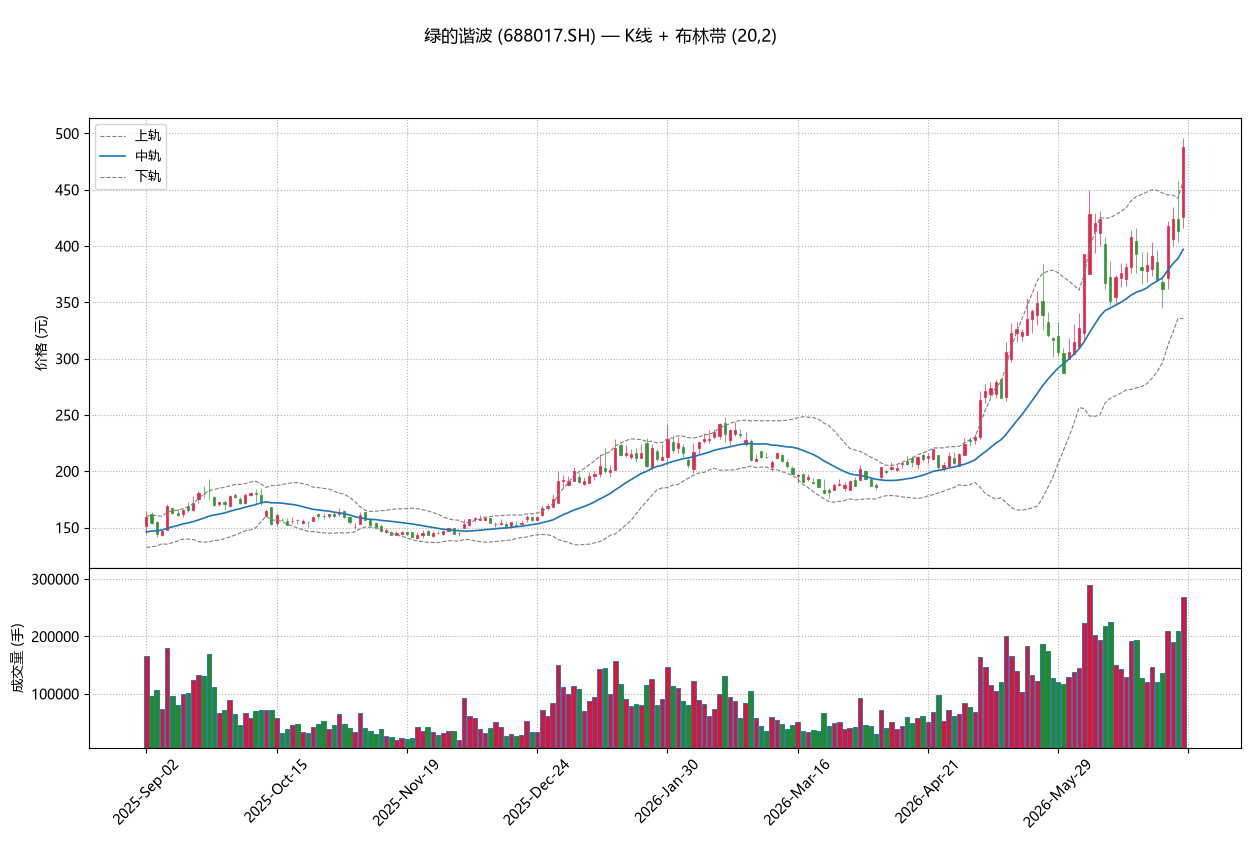

In [7]:
# ============================================================
# 可视化 1: K线 + 布林带 + 成交量
# ============================================================
plt.rcParams.update(FONT_RC)  # 确保中文字体生效

# 选取最近 200 个交易日展示
DISPLAY_N = min(200, len(df))
df_disp = df.tail(DISPLAY_N).copy().set_index('date')

# 配色: A股惯例 涨红跌绿
RED   = '#DC143C'
GREEN = '#228B22'
BLUE  = '#1f77b4'

mc = mpf.make_marketcolors(up=RED, down=GREEN, edge='inherit', wick='inherit', volume='inherit')
s  = mpf.make_mpf_style(marketcolors=mc, gridstyle=':', y_on_right=False, rc=FONT_RC)

apds = [
    mpf.make_addplot(df_disp['bb_upper'], color='gray', linestyle='--', width=0.8, label='上轨'),
    mpf.make_addplot(df_disp['bb_mid'],   color=BLUE, width=1.2, label='中轨'),
    mpf.make_addplot(df_disp['bb_lower'], color='gray', linestyle='--', width=0.8, label='下轨'),
]

fig1, axes = mpf.plot(
    df_disp, type='candle', style=s, addplot=apds, volume=True,
    title='\n绿的谐波 (688017.SH) — K线 + 布林带 (20,2)',
    ylabel='价格 (元)', ylabel_lower='成交量 (手)',
    figsize=(16, 9), returnfig=True, warn_too_much_data=10000,
)
axes[0].legend(loc='upper left', fontsize=9)
plt.show()

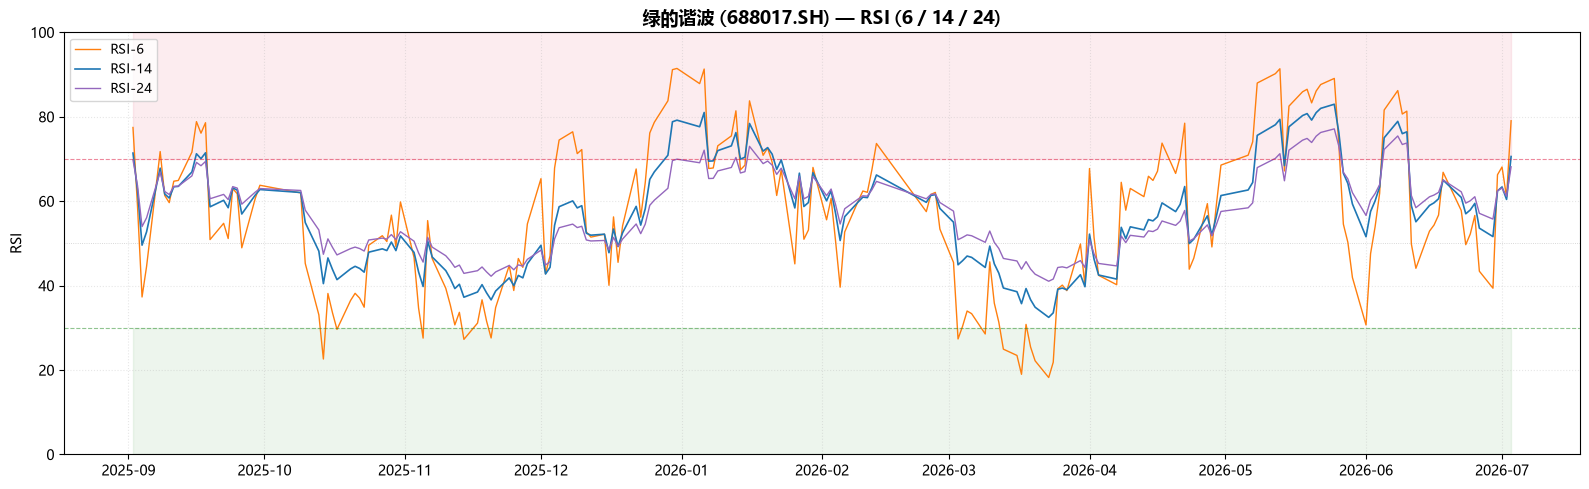

In [8]:
# ============================================================
# 可视化 2: RSI 三线
# ============================================================
plt.rcParams.update(FONT_RC)
fig2, ax = plt.subplots(figsize=(16, 5))

ax.plot(df_disp.index, df['rsi_6'].tail(DISPLAY_N),  color='#ff7f0e', linewidth=1,   label='RSI-6')
ax.plot(df_disp.index, df['rsi_14'].tail(DISPLAY_N), color=BLUE,        linewidth=1.2, label='RSI-14')
ax.plot(df_disp.index, df['rsi_24'].tail(DISPLAY_N), color='#9467bd',   linewidth=1,   label='RSI-24')

# 超买超卖区间
ax.axhline(y=70, color=RED,   linestyle='--', alpha=0.5, linewidth=0.8)
ax.axhline(y=30, color=GREEN, linestyle='--', alpha=0.5, linewidth=0.8)
ax.axhline(y=50, color='gray', linestyle=':',  alpha=0.4, linewidth=0.6)
ax.fill_between(df_disp.index, 70, 100, alpha=0.08, color=RED)
ax.fill_between(df_disp.index, 0,  30,  alpha=0.08, color=GREEN)
ax.set_ylim(0, 100)
ax.set_ylabel('RSI')
ax.set_title('绿的谐波 (688017.SH) — RSI (6 / 14 / 24)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
fig2.tight_layout()
plt.show()

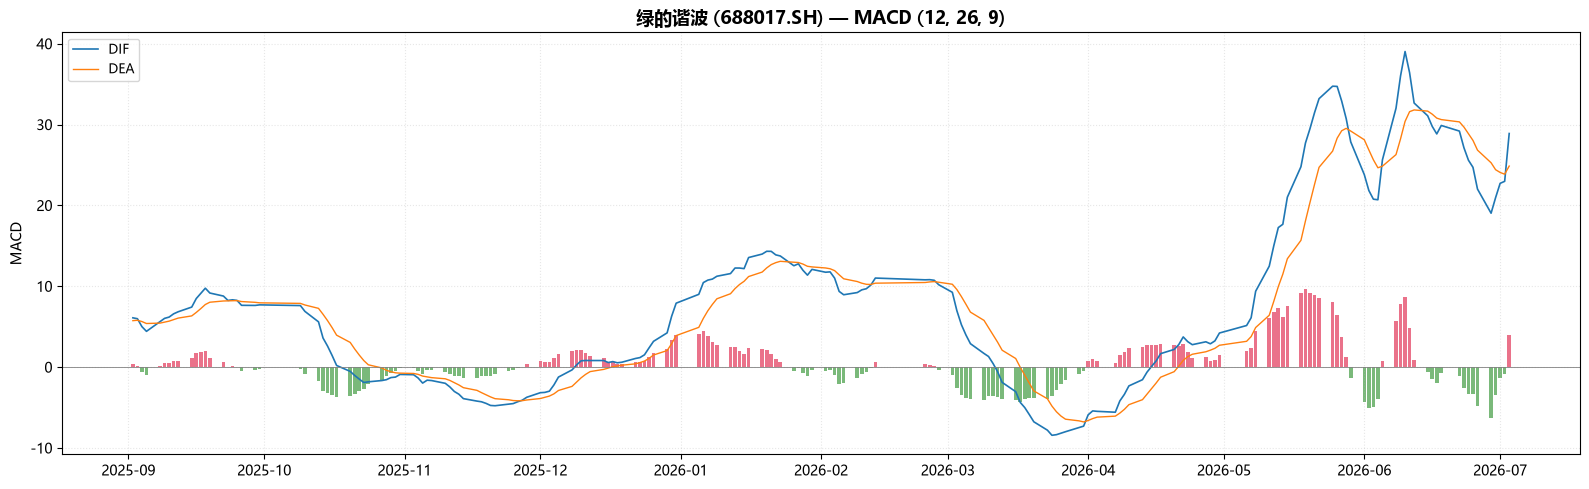

In [9]:
# ============================================================
# 可视化 3: MACD
# ============================================================
plt.rcParams.update(FONT_RC)
fig3, ax = plt.subplots(figsize=(16, 5))

# 柱状图：正值红色，负值绿色
hist_vals = df['macd_hist'].tail(DISPLAY_N).values
colors = [RED if v >= 0 else GREEN for v in hist_vals]
ax.bar(df_disp.index, hist_vals, color=colors, width=0.8, alpha=0.6)

ax.plot(df_disp.index, df['dif'].tail(DISPLAY_N), color=BLUE,        linewidth=1.2, label='DIF')
ax.plot(df_disp.index, df['dea'].tail(DISPLAY_N), color='#ff7f0e',   linewidth=1,   label='DEA')
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.6)
ax.set_ylabel('MACD')
ax.set_title('绿的谐波 (688017.SH) — MACD (12, 26, 9)', fontsize=13, fontweight='bold')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
fig3.tight_layout()
plt.show()

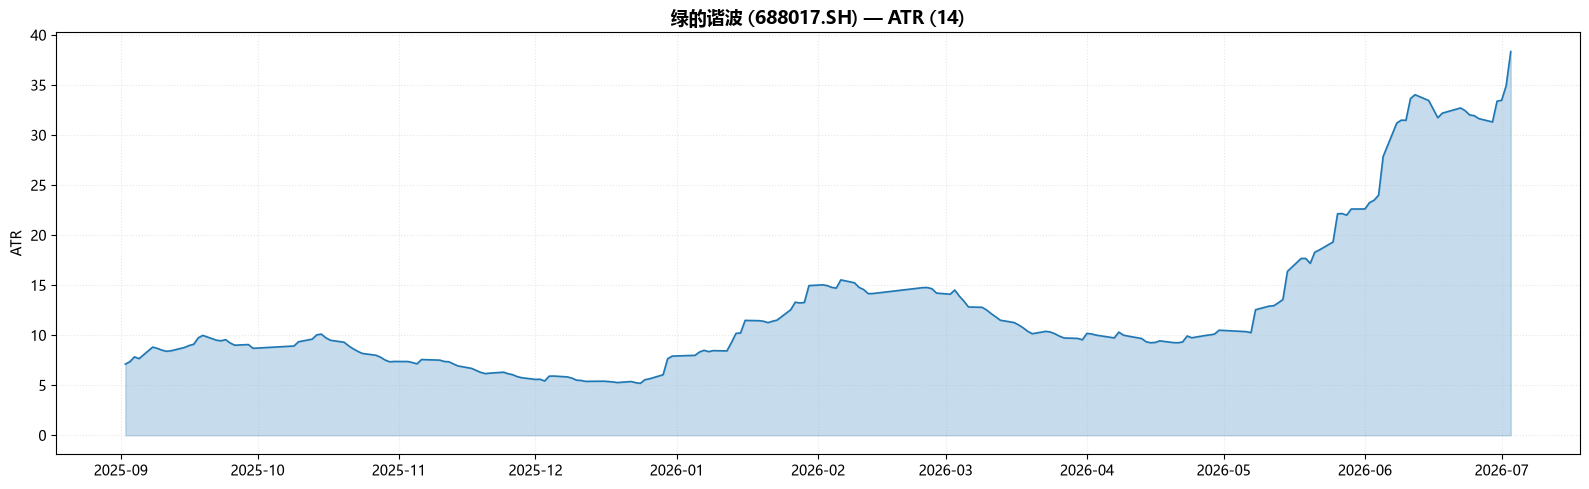

In [10]:
# ============================================================
# 可视化 4: ATR
# ============================================================
plt.rcParams.update(FONT_RC)
fig4, ax = plt.subplots(figsize=(16, 5))

atr_vals = df['atr'].tail(DISPLAY_N).values
ax.fill_between(df_disp.index, atr_vals, alpha=0.25, color=BLUE)
ax.plot(df_disp.index, atr_vals, color=BLUE, linewidth=1.2)
ax.set_ylabel('ATR')
ax.set_title('绿的谐波 (688017.SH) — ATR (14)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
fig4.tight_layout()
plt.show()

In [11]:
# ============================================================
# 综合统计摘要
# ============================================================
latest = df.iloc[-1]
close_series = df['close']

summary = pd.DataFrame({
    '指标': [
        '收盘价',
        'N日最高', 'N日最低',
        '20日均价', '60日均价',
        '日波动率(年化)',
        'RSI-6', 'RSI-14', 'RSI-24',
        'DIF', 'DEA', 'MACD Hist',
        '布林上轨', '布林中轨', '布林下轨',
        '布林带宽(%)', '%B',
        'ATR(14)',
        'ATR/Close(%)',
    ],
    '最新值': [
        f"{latest['close']:.2f}",
        f"{close_series.max():.2f}", f"{close_series.min():.2f}",
        f"{close_series.tail(20).mean():.2f}", f"{close_series.tail(60).mean():.2f}",
        f"{close_series.pct_change().std() * np.sqrt(252) * 100:.2f}%",
        f"{latest['rsi_6']:.2f}", f"{latest['rsi_14']:.2f}", f"{latest['rsi_24']:.2f}",
        f"{latest['dif']:.4f}", f"{latest['dea']:.4f}", f"{latest['macd_hist']:.4f}",
        f"{latest['bb_upper']:.2f}", f"{latest['bb_mid']:.2f}", f"{latest['bb_lower']:.2f}",
        f"{latest['bb_bandwidth']:.2f}%", f"{latest['bb_pct_b']:.4f}",
        f"{latest['atr']:.4f}",
        f"{latest['atr'] / latest['close'] * 100:.2f}%",
    ]
})
print(f'数据日期: {df["date"].iloc[-1].date()}   股票: 绿的谐波 688017.SH\n')
summary

数据日期: 2026-07-03   股票: 绿的谐波 688017.SH



,指标,最新值
0,收盘价,488.00
1,N日最高,488.00
2,N日最低,115.12
3,20日均价,397.09
4,60日均价,305.28
5,日波动率(年化),66.27%
6,RSI-6,79.05
7,RSI-14,70.58
8,RSI-24,68.15
9,DIF,28.8911


## 总结与备注

### 分析结论
以上四项技术指标从不同维度刻画了绿的谐波的走势特征：
- **RSI** 反映价格运动的内在强弱，辅以超买/超卖信号
- **MACD** 追踪趋势方向与动能变化，通过金叉/死叉给出交易信号
- **布林带** 衡量价格偏离均线的程度，识别波动率变化
- **ATR** 量化市场波动幅度，辅助仓位管理与止损设定

### 注意事项
- 技术指标仅供参考，不构成投资建议
- 单一指标存在局限性，建议结合基本面与市场环境综合判断
- ATR 不指示方向，应配合趋势类指标（如 MACD）共同使用
- 布林带在横盘市场参考价值较高，强趋势中价格可能持续贴边运行

### 指标参数汇总
| 指标 | 参数 |
|------|------|
| RSI | 6 / 14 / 24 |
| MACD | Fast=12, Slow=26, Signal=9, Hist=DIFF-DEA |
| 布林带 | Period=20, K=2 |
| ATR | Period=14 |

---
*生成日期: 2026-07-04 | 数据来源: Tushare*